In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv("Advertising.csv")

In [6]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [7]:
df.shape

(200, 4)

In [8]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [10]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


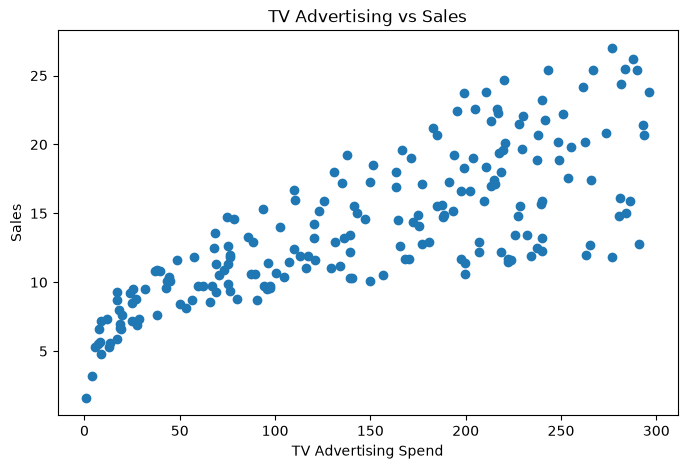

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(df["TV"], df["Sales"])

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")

plt.show()

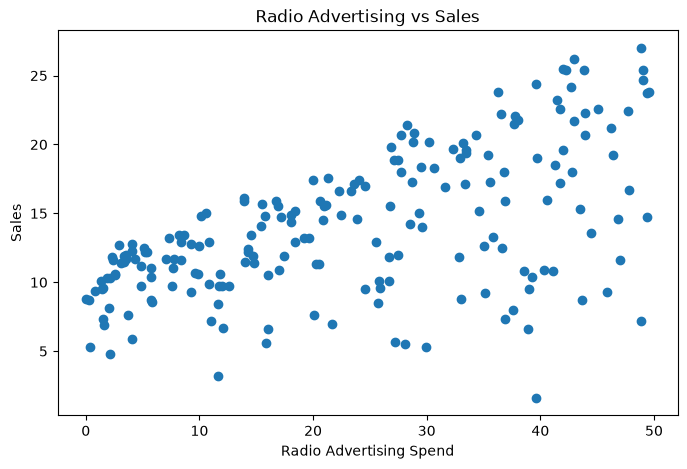

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Radio"], df["Sales"])

plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")

plt.show()

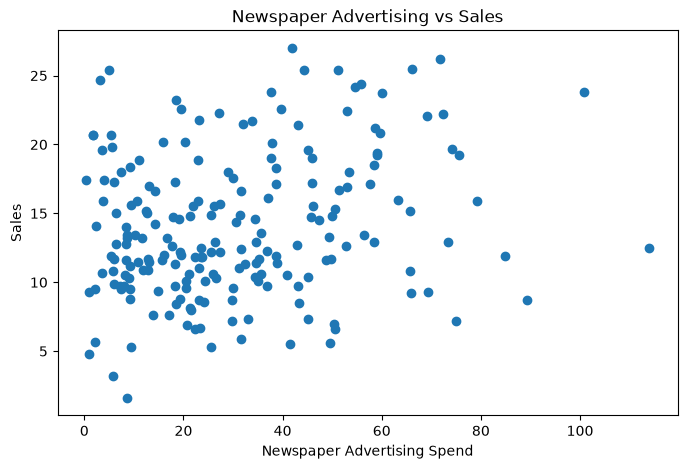

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Newspaper"], df["Sales"])

plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")

plt.show()

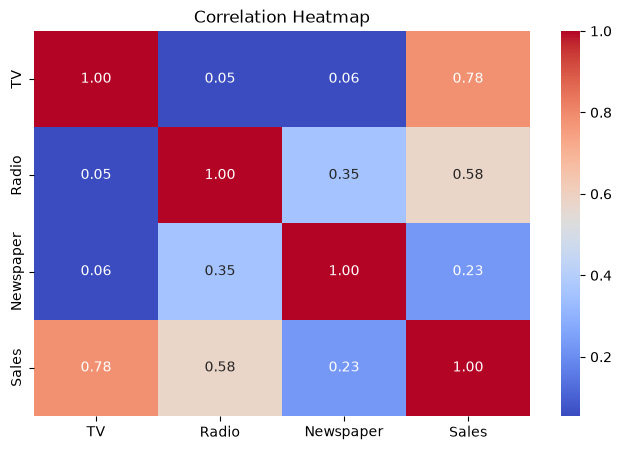

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [17]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target (y):
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.4607567168117603
Root Mean Squared Error (RMSE): 1.78159966153345
R² Score: 0.899438024100912


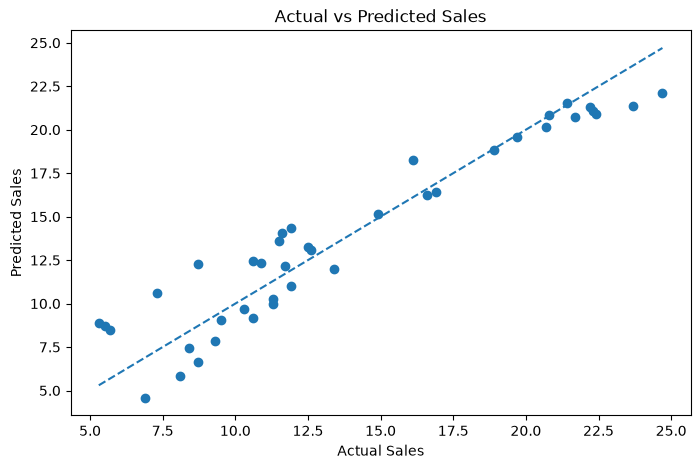

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [23]:
sales_correlation = df.corr()["Sales"].sort_values(ascending=False)

print(sales_correlation)

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


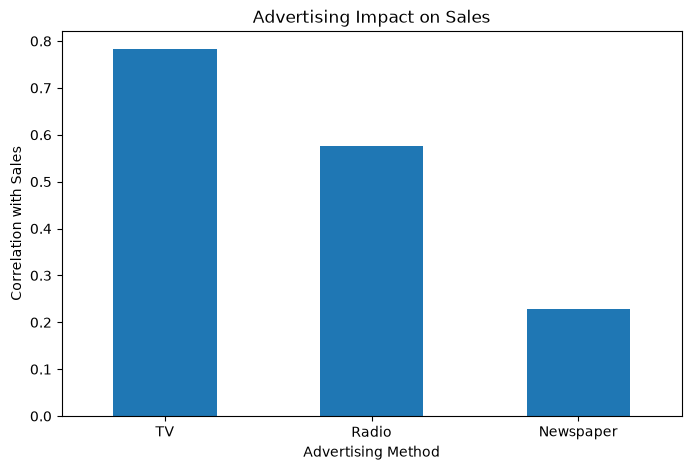

In [24]:
correlations = df.corr()["Sales"].drop("Sales")

plt.figure(figsize=(8, 5))

correlations.plot(kind="bar")

plt.xlabel("Advertising Method")
plt.ylabel("Correlation with Sales")
plt.title("Advertising Impact on Sales")

plt.xticks(rotation=0)

plt.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_pred[:10])

Random Forest Predictions:
[17.698 21.804 20.619  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]


In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 0.6203249999999988
Random Forest RMSE: 0.7687170968568338
Random Forest R² Score: 0.9812782416450916


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620325,0.768717,0.981278


In [29]:
new_advertising = pd.DataFrame({
    "TV": [100],
    "Radio": [25],
    "Newspaper": [20]
})

predicted_sales = model.predict(new_advertising)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 12.237117727681019


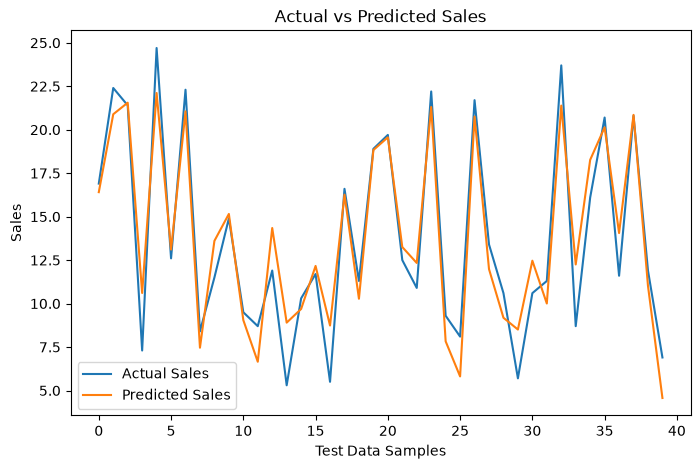

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")

plt.xlabel("Test Data Samples")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()

plt.show()

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
0         TV    0.624810
1      Radio    0.362214
2  Newspaper    0.012976


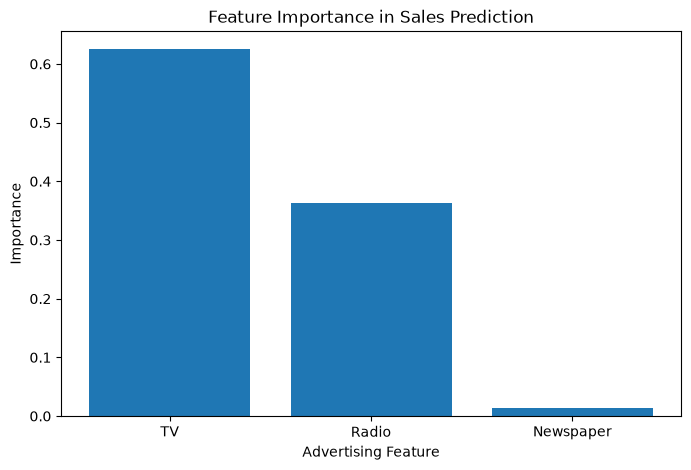

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Advertising Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Sales Prediction")

plt.show()

## Conclusion

In this project, a Sales Prediction system was developed using Python and Machine Learning.

The Advertising dataset was analyzed to understand the relationship between advertising expenditure and sales. The data was checked for missing values and duplicate records, and exploratory data analysis was performed using different visualizations.

Two regression models were developed:
- Linear Regression
- Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The models were also used to predict sales for new advertising expenditure values.

Feature importance analysis was performed using the Random Forest model to understand the contribution of TV, Radio, and Newspaper advertising to sales prediction.

Overall, the project demonstrates how Machine Learning can be used to analyze advertising data and predict sales based on advertising expenditure.